In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
LOGINS_PATH = "C:\\Users\\Muhammad\\SpringboardProjects\\SpringboardProjectv2\\ultimate_challenge\\logins.json"
ULTIMATE_CSV_PATH = "C:\\Users\\Muhammad\\SpringboardProjects\\SpringboardProjectv2\\ultimate_challenge\\ultimate_data_challenge.csv"

LOGINS_PATH, ULTIMATE_CSV_PATH

('C:\\Users\\Muhammad\\SpringboardProjects\\SpringboardProjectv2\\ultimate_challenge\\logins.json',
 'C:\\Users\\Muhammad\\SpringboardProjects\\SpringboardProjectv2\\ultimate_challenge\\ultimate_data_challenge.csv')

In [6]:
logins = pd.read_json(LOGINS_PATH)

if "login_time" not in logins.columns:
    raise ValueError(f"Expected a 'login_time' column. Found columns: {logins.columns.tolist()}")

logins["login_time"] = pd.to_datetime(logins["login_time"], errors="coerce")
logins = logins.dropna(subset=["login_time"]).sort_values("login_time").reset_index(drop=True)

logins.head(), logins.shape

(           login_time
 0 1970-01-01 20:12:16
 1 1970-01-01 20:13:18
 2 1970-01-01 20:16:10
 3 1970-01-01 20:16:36
 4 1970-01-01 20:16:37,
 (93142, 1))

In [7]:
logins["login_time"].min(), logins["login_time"].max(), logins["login_time"].isna().mean(), logins.duplicated(["login_time"]).mean()

(Timestamp('1970-01-01 20:12:16'),
 Timestamp('1970-04-13 18:57:38'),
 0.0,
 0.009415730819608769)

In [8]:
login_15 = (
    logins.assign(count=1)
    .set_index("login_time")["count"]
    .resample("15min")
    .sum()
    .asfreq("15min", fill_value=0)
)

login_15.head(), login_15.shape

(login_time
 1970-01-01 20:00:00    2
 1970-01-01 20:15:00    6
 1970-01-01 20:30:00    9
 1970-01-01 20:45:00    7
 1970-01-01 21:00:00    1
 Freq: 15min, Name: count, dtype: int64,
 (9788,))

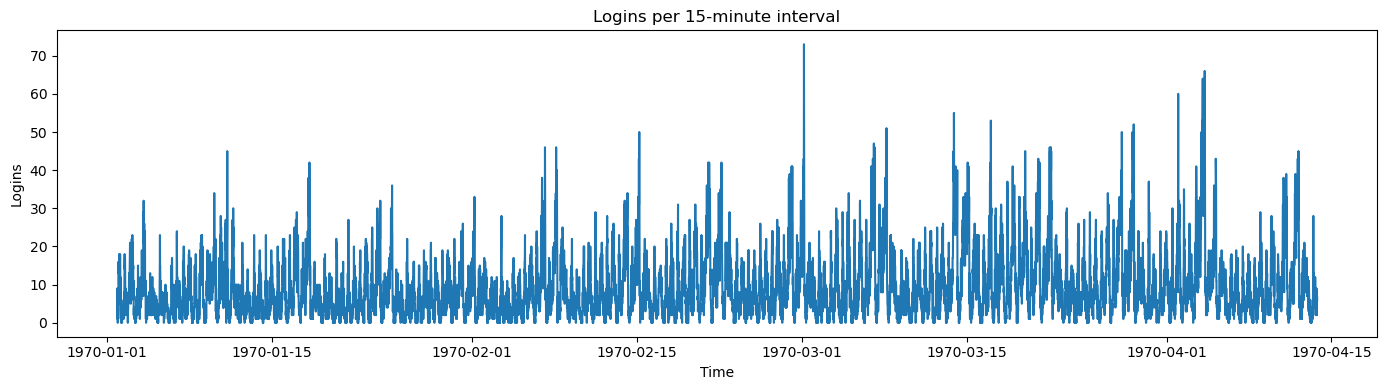

In [9]:
plt.figure(figsize=(14,4))
plt.plot(login_15.index, login_15.values)
plt.title("Logins per 15-minute interval")
plt.xlabel("Time")
plt.ylabel("Logins")
plt.tight_layout()
plt.show()

In [10]:
login_15.describe()

count    9788.000000
mean        9.515938
std         8.328818
min         0.000000
25%         3.000000
50%         7.000000
75%        13.000000
max        73.000000
Name: count, dtype: float64

In [33]:
hourly = login_15.resample("1h").sum()
daily = login_15.resample("1D").sum()

hourly.describe(), daily.describe()

(count    2447.000000
 mean       38.063752
 std        30.752820
 min         0.000000
 25%        15.000000
 50%        29.000000
 75%        52.000000
 max       237.000000
 Name: count, dtype: float64,
 count     103.000000
 mean      904.291262
 std       347.167463
 min       112.000000
 25%       643.000000
 50%       827.000000
 75%      1141.000000
 max      1889.000000
 Name: count, dtype: float64)

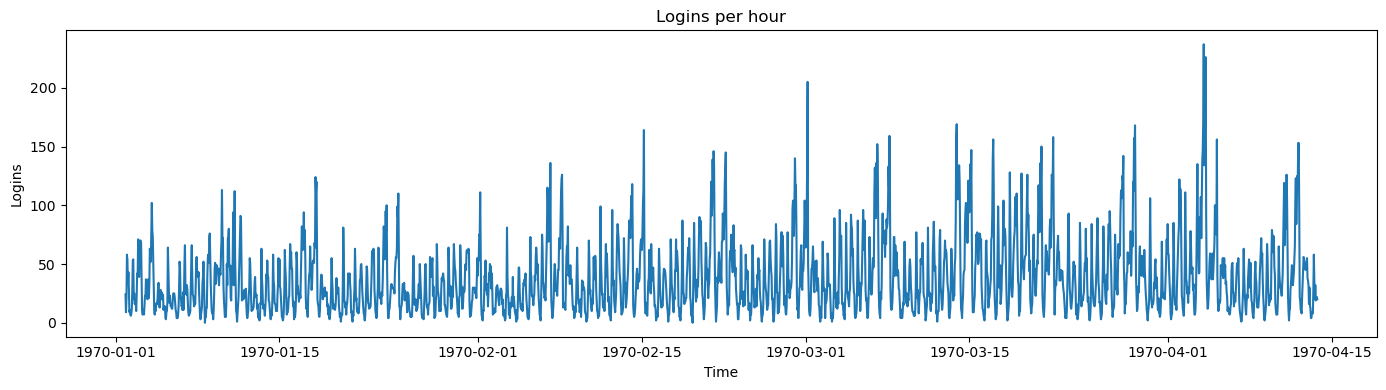

In [12]:
plt.figure(figsize=(14,4))
plt.plot(hourly.index, hourly.values)
plt.title("Logins per hour")
plt.xlabel("Time")
plt.ylabel("Logins")
plt.tight_layout()
plt.show()

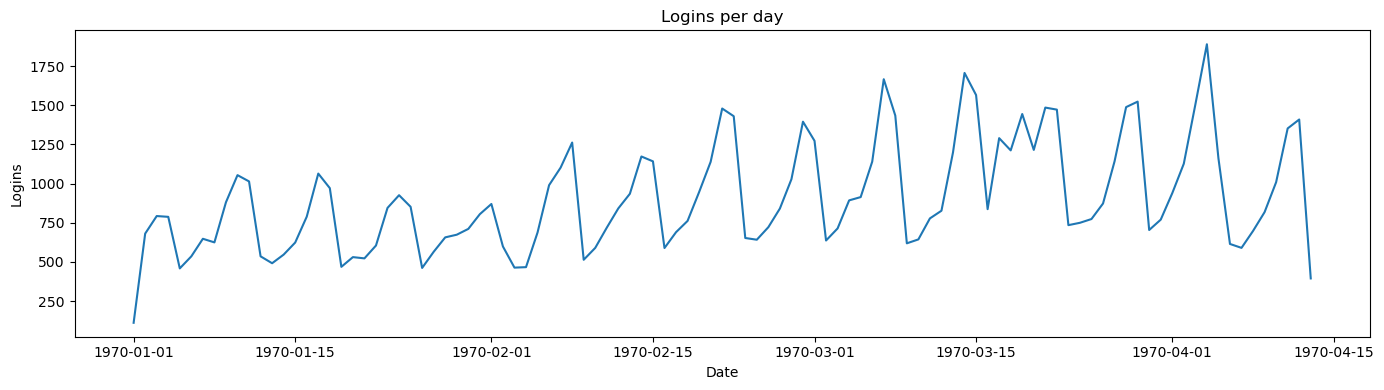

In [13]:
plt.figure(figsize=(14,4))
plt.plot(daily.index, daily.values)
plt.title("Logins per day")
plt.xlabel("Date")
plt.ylabel("Logins")
plt.tight_layout()
plt.show()

In [14]:
by_dow = login_15.groupby(login_15.index.day_name()).mean()
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
by_dow = by_dow.reindex(dow_order)
by_dow

login_time
Monday        6.213380
Tuesday       6.895833
Wednesday     7.692708
Thursday      8.794118
Friday       10.561111
Saturday     13.456250
Sunday       12.615972
Name: count, dtype: float64

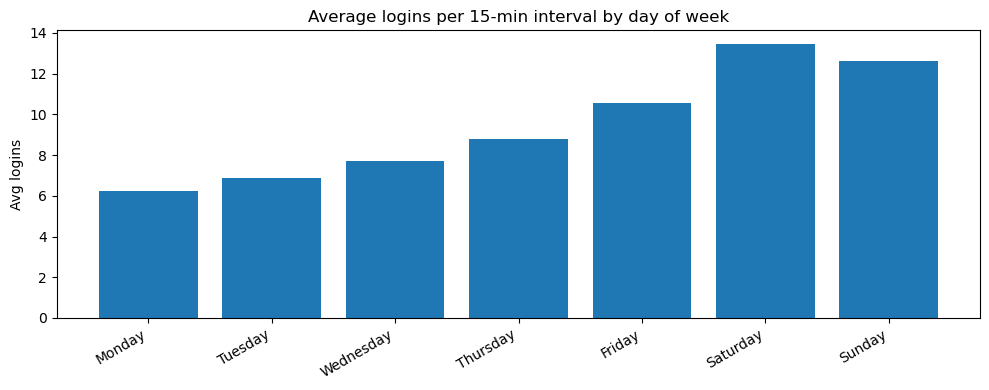

In [15]:
plt.figure(figsize=(10,4))
plt.bar(by_dow.index, by_dow.values)
plt.title("Average logins per 15-min interval by day of week")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Avg logins")
plt.tight_layout()
plt.show()

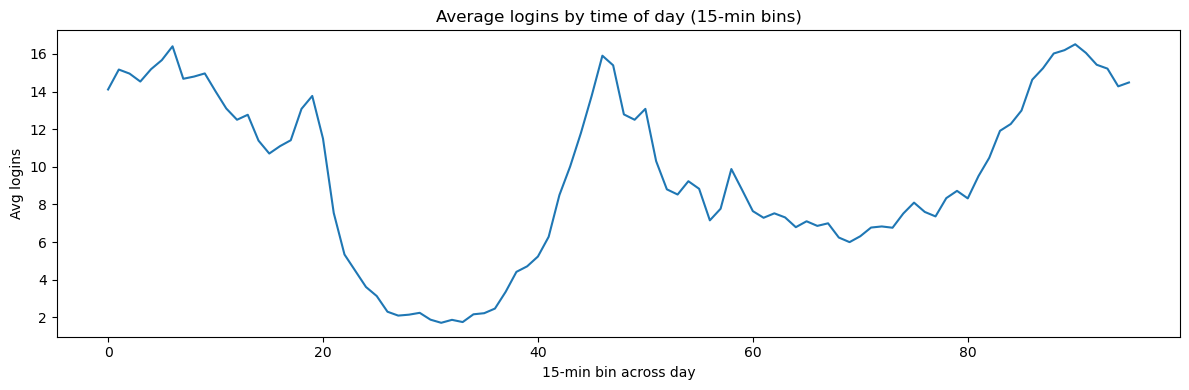

In [16]:
tod = login_15.groupby(login_15.index.time).mean().sort_index()
plt.figure(figsize=(12,4))
plt.plot(range(len(tod)), tod.values)
plt.title("Average logins by time of day (15-min bins)")
plt.xlabel("15-min bin across day")
plt.ylabel("Avg logins")
plt.tight_layout()
plt.show()

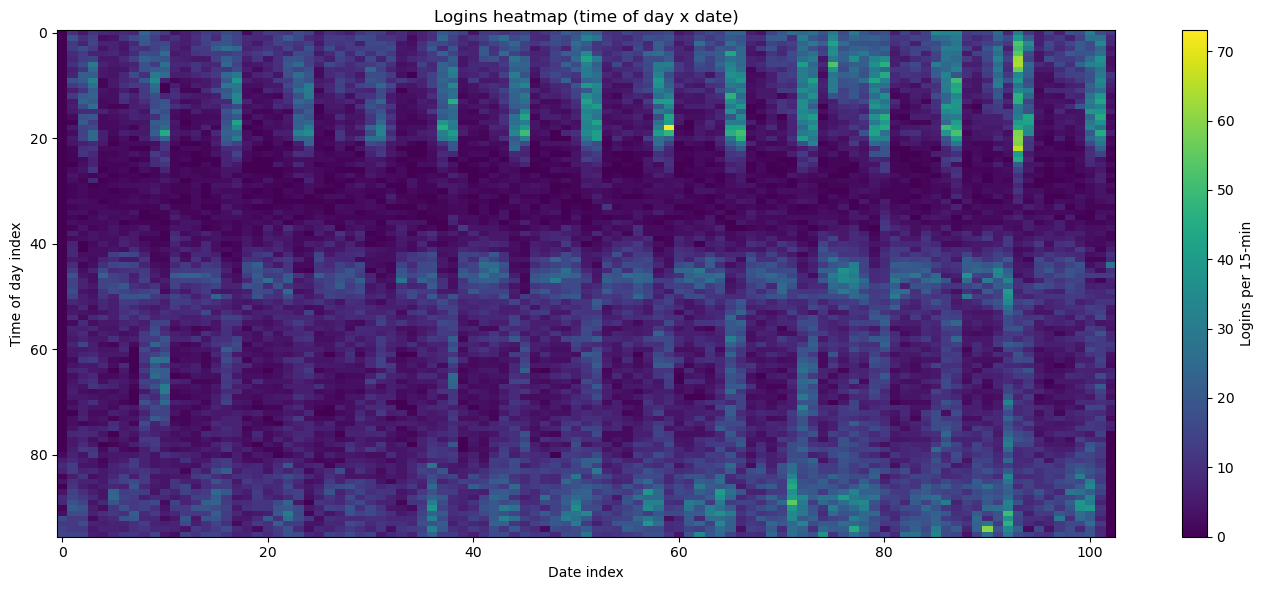

In [17]:
heat_df = login_15.to_frame("count")
heat_df["date"] = heat_df.index.date
heat_df["time"] = heat_df.index.time
pivot = heat_df.pivot_table(index="time", columns="date", values="count", aggfunc="sum").fillna(0)

plt.figure(figsize=(14,6))
plt.imshow(pivot.values, aspect="auto", interpolation="nearest")
plt.title("Logins heatmap (time of day x date)")
plt.xlabel("Date index")
plt.ylabel("Time of day index")
plt.colorbar(label="Logins per 15-min")
plt.tight_layout()
plt.show()

In [18]:
ultimate = pd.read_csv(ULTIMATE_CSV_PATH)
ultimate.shape, ultimate.columns.tolist()

((50000, 12),
 ['city',
  'trips_in_first_30_days',
  'signup_date',
  'avg_rating_of_driver',
  'avg_surge',
  'last_trip_date',
  'phone',
  'surge_pct',
  'ultimate_black_user',
  'weekday_pct',
  'avg_dist',
  'avg_rating_by_driver'])

In [19]:
ultimate.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


In [20]:
for c in ["signup_date", "last_trip_date"]:
    if c not in ultimate.columns:
        raise ValueError(f"Missing required column: {c}. Found columns: {ultimate.columns.tolist()}")
    s = ultimate[c].astype("string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    ultimate[c] = pd.to_datetime(s, errors="coerce", infer_datetime_format=True)

ultimate[["signup_date","last_trip_date"]].isna().mean(), ultimate["last_trip_date"].max()

C:\Users\Muhammad\AppData\Local\Temp\ipykernel_2824\4079103527.py:6: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  ultimate[c] = pd.to_datetime(s, errors="coerce", infer_datetime_format=True)
C:\Users\Muhammad\AppData\Local\Temp\ipykernel_2824\4079103527.py:6: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  ultimate[c] = pd.to_datetime(s, errors="coerce", infer_datetime_format=True)


(signup_date       0.0
 last_trip_date    0.0
 dtype: float64,
 Timestamp('2014-07-01 00:00:00'))

In [21]:
max_last_trip = ultimate["last_trip_date"].max()
if pd.isna(max_last_trip):
    raise ValueError("last_trip_date could not be parsed (max is NaT). Inspect the raw values in last_trip_date.")

cutoff = max_last_trip - pd.Timedelta(days=30)
ultimate["retained"] = (ultimate["last_trip_date"] >= cutoff).astype(int)

ultimate["retained"].value_counts(), float(ultimate["retained"].mean()), max_last_trip, cutoff

(retained
 0    31196
 1    18804
 Name: count, dtype: int64,
 0.37608,
 Timestamp('2014-07-01 00:00:00'),
 Timestamp('2014-06-01 00:00:00'))

In [22]:
ultimate.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
city,50000,3,Winterfell,23336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trips_in_first_30_days,50000.0,NaN,NaN,NaN,2.2782,0.0,0.0,1.0,3.0,125.0,3.792684
signup_date,50000,NaN,NaN,NaN,2014-01-16 13:04:20.352000,2014-01-01 00:00:00,2014-01-09 00:00:00,2014-01-17 00:00:00,2014-01-24 00:00:00,2014-01-31 00:00:00,NaN
avg_rating_of_driver,41878.0,NaN,NaN,NaN,4.601559,1.0,4.3,4.9,5.0,5.0,0.617338
avg_surge,50000.0,NaN,NaN,NaN,1.074764,1.0,1.0,1.0,1.05,8.0,0.222336
last_trip_date,50000,NaN,NaN,NaN,2014-04-19 08:02:04.992000256,2014-01-01 00:00:00,2014-02-14 00:00:00,2014-05-08 00:00:00,2014-06-18 00:00:00,2014-07-01 00:00:00,NaN
phone,49604,2,iPhone,34582,NaN,NaN,NaN,NaN,NaN,NaN,NaN
surge_pct,50000.0,NaN,NaN,NaN,8.849536,0.0,0.0,0.0,8.6,100.0,19.958811
ultimate_black_user,50000,2,False,31146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weekday_pct,50000.0,NaN,NaN,NaN,60.926084,0.0,33.3,66.7,100.0,100.0,37.081503


In [23]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [24]:
df = ultimate.copy()

y = df["retained"].astype(int)
X = df.drop(columns=["retained", "last_trip_date"], errors="ignore")

for c in ["signup_date"]:
    if c in X.columns:
        X[c] = X[c].view("int64")

cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

y_train.value_counts(), y_test.value_counts(), cat_cols, num_cols

C:\Users\Muhammad\AppData\Local\Temp\ipykernel_2824\1199114956.py:8: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  X[c] = X[c].view("int64")


(retained
 0    23397
 1    14103
 Name: count, dtype: int64,
 retained
 0    7799
 1    4701
 Name: count, dtype: int64,
 ['city', 'phone'],
 ['trips_in_first_30_days',
  'signup_date',
  'avg_rating_of_driver',
  'avg_surge',
  'surge_pct',
  'ultimate_black_user',
  'weekday_pct',
  'avg_dist',
  'avg_rating_by_driver'])

In [25]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)

In [26]:
models = {
    "logreg": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "rf": RandomForestClassifier(
        n_estimators=500, random_state=42, class_weight="balanced_subsample", n_jobs=-1
    ),
    "gb": GradientBoostingClassifier(random_state=42)
}

rows = []
fitted = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:,1] if hasattr(pipe.named_steps["model"], "predict_proba") else None

    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba) if proba is not None else np.nan
    })
    fitted[name] = pipe

results_df = pd.DataFrame(rows).sort_values("roc_auc", ascending=False)
results_df

,model,accuracy,precision,recall,f1,roc_auc
2,gb,0.78744,0.741265,0.667943,0.702697,0.852138
1,rf,0.77320,0.720151,0.649224,0.682850,0.840975
0,logreg,0.62392,0.000000,0.000000,0.000000,0.511573


In [27]:
best_name = results_df.iloc[0]["model"]
best_pipe = fitted[best_name]
best_name

'gb'

In [28]:
best_pred = best_pipe.predict(X_test)
best_proba = best_pipe.predict_proba(X_test)[:,1]

cm = confusion_matrix(y_test, best_pred)
cm

array([[6703, 1096],
       [1561, 3140]], dtype=int64)

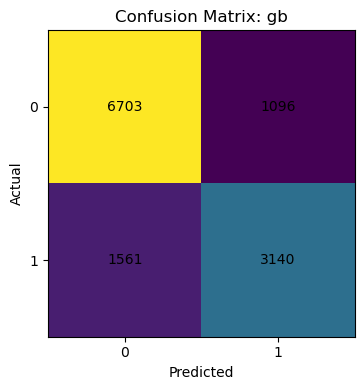

In [29]:
plt.figure(figsize=(4,4))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix: {best_name}")
plt.xticks([0,1],[0,1])
plt.yticks([0,1],[0,1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [30]:
print(classification_report(y_test, best_pred, digits=3))

              precision    recall  f1-score   support

           0      0.811     0.859     0.835      7799
           1      0.741     0.668     0.703      4701

    accuracy                          0.787     12500
   macro avg      0.776     0.764     0.769     12500
weighted avg      0.785     0.787     0.785     12500



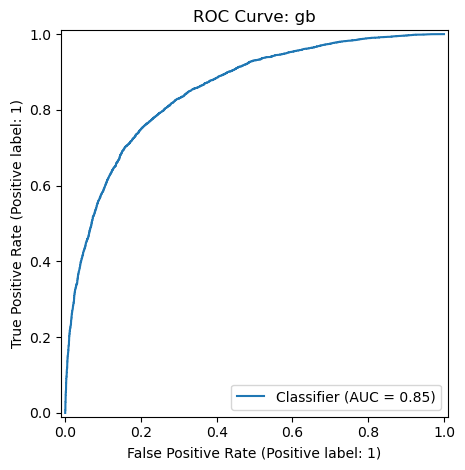

In [31]:
RocCurveDisplay.from_predictions(y_test, best_proba)
plt.title(f"ROC Curve: {best_name}")
plt.tight_layout()
plt.show()

In [34]:
from sklearn.inspection import permutation_importance
import pandas as pd

perm = permutation_importance(
    best_pipe, X_test, y_test,
    n_repeats=15, random_state=42, scoring="roc_auc"
)

imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
imp.head(20)

city                      0.058058
weekday_pct               0.042961
avg_rating_by_driver      0.028528
phone                     0.025195
surge_pct                 0.017941
ultimate_black_user       0.017497
trips_in_first_30_days    0.017029
avg_dist                  0.005859
avg_rating_of_driver      0.002023
avg_surge                 0.000632
signup_date               0.000308
dtype: float64

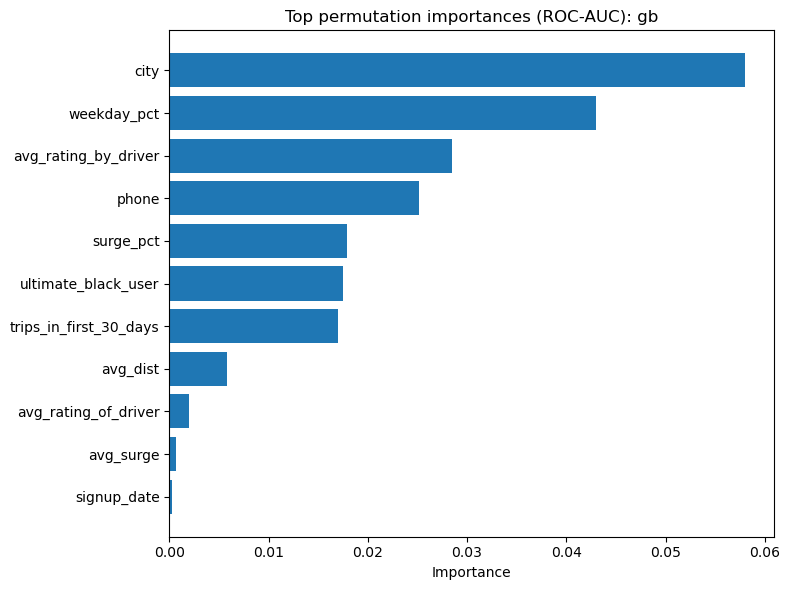

In [35]:
top = imp.head(20).sort_values()
plt.figure(figsize=(8,6))
plt.barh(top.index, top.values)
plt.title(f"Top permutation importances (ROC-AUC): {best_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()